# BD PowerCast — Custom Model B

## Adaptive Gated Ramp-Aware Temporal Network

### Motivation

Custom Model A achieved a validation MAPE of 1.7805%, outperforming
the traditional LightGBM benchmark of 1.9309%.

Error analysis showed higher forecasting errors around rapid demand-transition
periods, particularly around 13:00, 17:00, and 18:00.

Custom Model B therefore introduces:

1. A dedicated ramp/change branch.
2. Adaptive weighting between recent, daily, weekly, and ramp information.
3. Calendar-conditioned temporal fusion.

### Benchmark to Beat

Custom Model A Validation MAPE = 1.7805%

The final test set will not be used during Model B development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import random
import copy
import time

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
GPU: NVIDIA GeForce RTX 5050


In [2]:
df = pd.read_csv(
    "../data/processed/PGCB_hourly_preprocessed_stage6_continuous.csv",
    parse_dates=["datetime"]
)

print("Dataset shape:", df.shape)

Dataset shape: (89101, 61)


create lag features

In [3]:
# Recent lags
df["lag_1"] = df["demand_mw_clean"].shift(1)
df["lag_2"] = df["demand_mw_clean"].shift(2)
df["lag_3"] = df["demand_mw_clean"].shift(3)

# Daily lags
df["lag_24"] = df["demand_mw_clean"].shift(24)
df["lag_48"] = df["demand_mw_clean"].shift(48)
df["lag_72"] = df["demand_mw_clean"].shift(72)

# Weekly lags
df["lag_168"] = df["demand_mw_clean"].shift(168)
df["lag_336"] = df["demand_mw_clean"].shift(336)
df["lag_504"] = df["demand_mw_clean"].shift(504)
df["lag_672"] = df["demand_mw_clean"].shift(672)

print("Lag features created.")

Lag features created.


rolling features

In [4]:
past_demand = df["demand_mw_clean"].shift(1)

df["rolling_mean_3"] = past_demand.rolling(3).mean()
df["rolling_mean_6"] = past_demand.rolling(6).mean()

df["rolling_mean_24"] = past_demand.rolling(24).mean()
df["rolling_std_24"] = past_demand.rolling(24).std()
df["rolling_max_24"] = past_demand.rolling(24).max()
df["rolling_min_24"] = past_demand.rolling(24).min()

df["rolling_mean_168"] = past_demand.rolling(168).mean()

print("Rolling features created.")

Rolling features created.


calendar features

In [5]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

df["month_sin"] = np.sin(
    2 * np.pi * (df["month"] - 1) / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * (df["month"] - 1) / 12
)

df["is_friday"] = (
    df["day_of_week"] == 4
).astype(int)

print("Calendar features created.")

Calendar features created.


new Model B ramp features

In [6]:
# Hour-to-hour recent changes
df["change_1"] = (
    df["demand_mw_clean"].shift(1)
    - df["demand_mw_clean"].shift(2)
)

df["change_2"] = (
    df["demand_mw_clean"].shift(2)
    - df["demand_mw_clean"].shift(3)
)

df["change_3"] = (
    df["demand_mw_clean"].shift(3)
    - df["demand_mw_clean"].shift(4)
)

# Difference between current recent behavior
# and historical periodic behavior
df["recent_vs_daily"] = (
    df["lag_1"] - df["lag_24"]
)

df["recent_vs_weekly"] = (
    df["lag_1"] - df["lag_168"]
)

# Recent demand range
df["rolling_max_6"] = (
    past_demand.rolling(6).max()
)

df["rolling_min_6"] = (
    past_demand.rolling(6).min()
)

df["range_6"] = (
    df["rolling_max_6"]
    - df["rolling_min_6"]
)

# Short-term volatility
df["rolling_std_6"] = (
    past_demand.rolling(6).std()
)

print("Ramp features created.")

Ramp features created.


define Model B branches

In [7]:
recent_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_24"
]

daily_features = [
    "lag_24",
    "lag_48",
    "lag_72",
    "rolling_mean_24",
    "rolling_max_24",
    "rolling_min_24"
]

weekly_features = [
    "lag_168",
    "lag_336",
    "lag_504",
    "lag_672",
    "rolling_mean_168"
]

calendar_features = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "is_friday"
]

ramp_features = [
    "change_1",
    "change_2",
    "change_3",
    "recent_vs_daily",
    "recent_vs_weekly",
    "range_6",
    "rolling_std_6"
]

target = "demand_mw_clean"

build Model B dataframe

In [9]:
all_features_b = (
    recent_features
    + daily_features
    + weekly_features
    + calendar_features
    + ramp_features
)

custom_b_df = df[
    ["datetime", "row_observed", target]
    + all_features_b
].copy()

custom_b_df = custom_b_df[
    custom_b_df["row_observed"] == 1
]

custom_b_df = custom_b_df.dropna(
    subset=[target] + all_features_b
).reset_index(drop=True)

print("Model B dataset shape:", custom_b_df.shape)

print(
    "Remaining missing values:",
    custom_b_df[all_features_b + [target]]
    .isnull()
    .sum()
    .sum()
)

Model B dataset shape: (58429, 34)
Remaining missing values: 0


same chronological split

In [10]:
train_b = custom_b_df[
    custom_b_df["datetime"] < "2023-01-01"
].copy()

val_b = custom_b_df[
    (custom_b_df["datetime"] >= "2023-01-01") &
    (custom_b_df["datetime"] < "2024-01-01")
].copy()

test_b = custom_b_df[
    custom_b_df["datetime"] >= "2024-01-01"
].copy()

print("Train:", len(train_b))
print("Validation:", len(val_b))
print("Test:", len(test_b))

print("\nTrain range:")
print(train_b["datetime"].min(), "→", train_b["datetime"].max())

print("\nValidation range:")
print(val_b["datetime"].min(), "→", val_b["datetime"].max())

Train: 42521
Validation: 5662
Test: 10246

Train range:
2015-05-25 13:00:00 → 2022-12-31 23:00:00

Validation range:
2023-01-01 00:00:00 → 2023-12-30 20:00:00


create scalers

In [11]:
from sklearn.preprocessing import StandardScaler

recent_scaler_b = StandardScaler()
daily_scaler_b = StandardScaler()
weekly_scaler_b = StandardScaler()
calendar_scaler_b = StandardScaler()
ramp_scaler_b = StandardScaler()
target_scaler_b = StandardScaler()

scale training data

In [12]:
X_recent_train_b = recent_scaler_b.fit_transform(
    train_b[recent_features]
)

X_daily_train_b = daily_scaler_b.fit_transform(
    train_b[daily_features]
)

X_weekly_train_b = weekly_scaler_b.fit_transform(
    train_b[weekly_features]
)

X_calendar_train_b = calendar_scaler_b.fit_transform(
    train_b[calendar_features]
)

X_ramp_train_b = ramp_scaler_b.fit_transform(
    train_b[ramp_features]
)

y_train_b = target_scaler_b.fit_transform(
    train_b[[target]]
).flatten()

print("Training data scaled.")

Training data scaled.


scale validation data

In [13]:
X_recent_val_b = recent_scaler_b.transform(
    val_b[recent_features]
)

X_daily_val_b = daily_scaler_b.transform(
    val_b[daily_features]
)

X_weekly_val_b = weekly_scaler_b.transform(
    val_b[weekly_features]
)

X_calendar_val_b = calendar_scaler_b.transform(
    val_b[calendar_features]
)

X_ramp_val_b = ramp_scaler_b.transform(
    val_b[ramp_features]
)

y_val_b = target_scaler_b.transform(
    val_b[[target]]
).flatten()

print("Validation data scaled.")

Validation data scaled.


In [15]:
import torch

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

In [17]:
def to_tensor(data):
    return torch.tensor(
        data,
        dtype=torch.float32
    )

In [20]:
train_dataset_b = TensorDataset(
    to_tensor(X_recent_train_b),
    to_tensor(X_daily_train_b),
    to_tensor(X_weekly_train_b),
    to_tensor(X_calendar_train_b),
    to_tensor(X_ramp_train_b),
    to_tensor(y_train_b)
)

val_dataset_b = TensorDataset(
    to_tensor(X_recent_val_b),
    to_tensor(X_daily_val_b),
    to_tensor(X_weekly_val_b),
    to_tensor(X_calendar_val_b),
    to_tensor(X_ramp_val_b),
    to_tensor(y_val_b)
)

train_loader_b = DataLoader(
    train_dataset_b,
    batch_size=512,
    shuffle=True,
    pin_memory=True
)

val_loader_b = DataLoader(
    val_dataset_b,
    batch_size=1024,
    shuffle=False,
    pin_memory=True
)

print("Train samples:", len(train_dataset_b))
print("Validation samples:", len(val_dataset_b))

Train samples: 42521
Validation samples: 5662


set seed for reproducibility

In [21]:
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Random seed:", seed)

Random seed: 42


Adaptive Gated Ramp-Aware Network

In [22]:
class AdaptiveGatedDemandNet(nn.Module):

    def __init__(
        self,
        recent_dim,
        daily_dim,
        weekly_dim,
        calendar_dim,
        ramp_dim
    ):
        super().__init__()

        # ---------------------------
        # Recent branch
        # ---------------------------
        self.recent_branch = nn.Sequential(
            nn.Linear(recent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # ---------------------------
        # Daily branch
        # ---------------------------
        self.daily_branch = nn.Sequential(
            nn.Linear(daily_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # ---------------------------
        # Weekly branch
        # ---------------------------
        self.weekly_branch = nn.Sequential(
            nn.Linear(weekly_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # ---------------------------
        # Ramp/change branch
        # ---------------------------
        self.ramp_branch = nn.Sequential(
            nn.Linear(ramp_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # ---------------------------
        # Calendar branch
        # ---------------------------
        self.calendar_branch = nn.Sequential(
            nn.Linear(calendar_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        # ---------------------------
        # Adaptive gate
        # Calendar 8 + Ramp 16 = 24
        # Produces 4 branch weights
        # ---------------------------
        self.gate = nn.Sequential(
            nn.Linear(24, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

        # ---------------------------
        # Final fusion network
        # Weighted temporal = 16
        # Calendar = 8
        # Total = 24
        # ---------------------------
        self.fusion = nn.Sequential(
            nn.Linear(24, 48),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(48, 24),
            nn.ReLU(),

            nn.Linear(24, 1)
        )

    def forward(
        self,
        recent,
        daily,
        weekly,
        calendar,
        ramp
    ):

        # Branch representations
        recent_out = self.recent_branch(recent)
        daily_out = self.daily_branch(daily)
        weekly_out = self.weekly_branch(weekly)
        ramp_out = self.ramp_branch(ramp)
        calendar_out = self.calendar_branch(calendar)

        # ---------------------------
        # Calculate adaptive weights
        # ---------------------------
        gate_context = torch.cat(
            [
                calendar_out,
                ramp_out
            ],
            dim=1
        )

        gate_logits = self.gate(
            gate_context
        )

        gate_weights = torch.softmax(
            gate_logits,
            dim=1
        )

        # ---------------------------
        # Stack temporal branches
        #
        # Shape:
        # [batch, 4, 16]
        # ---------------------------
        branch_outputs = torch.stack(
            [
                recent_out,
                daily_out,
                weekly_out,
                ramp_out
            ],
            dim=1
        )

        # [batch, 4, 1]
        expanded_weights = (
            gate_weights.unsqueeze(-1)
        )

        # Adaptive weighted representation
        weighted_temporal = (
            branch_outputs
            * expanded_weights
        ).sum(dim=1)

        # Add calendar context
        combined = torch.cat(
            [
                weighted_temporal,
                calendar_out
            ],
            dim=1
        )

        prediction = self.fusion(
            combined
        )

        return (
            prediction.squeeze(1),
            gate_weights
        )

initialize Model B

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model_b = AdaptiveGatedDemandNet(
    recent_dim=len(recent_features),
    daily_dim=len(daily_features),
    weekly_dim=len(weekly_features),
    calendar_dim=len(calendar_features),
    ramp_dim=len(ramp_features)
).to(device)

print("Device:", device)

Device: cuda


parameter count

In [24]:
total_params_b = sum(
    p.numel()
    for p in model_b.parameters()
    if p.requires_grad
)

print(
    "Model B trainable parameters:",
    f"{total_params_b:,}"
)

Model B trainable parameters: 6,605


In [25]:
print(model_b)

AdaptiveGatedDemandNet(
  (recent_branch): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (daily_branch): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (weekly_branch): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (ramp_branch): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (calendar_branch): Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
  )
  (gate): Sequential(
    (0): Linear(in_feature

loss, optimizer, scheduler

In [26]:
criterion_b = nn.HuberLoss()

optimizer_b = torch.optim.AdamW(
    model_b.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler_b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b,
    mode="min",
    factor=0.5,
    patience=5
)

print("Model B training configuration ready.")

Model B training configuration ready.


early-stopping setup

In [27]:
import copy
import time

max_epochs = 150
patience = 15

best_val_mape_b = float("inf")
best_epoch_b = 0
best_state_b = None

patience_counter_b = 0

train_loss_history_b = []
val_loss_history_b = []
val_mape_history_b = []

print("Training setup complete.")

Training setup complete.


In [29]:
start_time_b = time.time()

for epoch in range(1, max_epochs + 1):

    # =====================================
    # TRAIN
    # =====================================
    model_b.train()

    total_train_loss = 0.0

    for batch in train_loader_b:

        recent, daily, weekly, calendar, ramp, y = batch

        recent = recent.to(device, non_blocking=True)
        daily = daily.to(device, non_blocking=True)
        weekly = weekly.to(device, non_blocking=True)
        calendar = calendar.to(device, non_blocking=True)
        ramp = ramp.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer_b.zero_grad()

        predictions, _ = model_b(
            recent,
            daily,
            weekly,
            calendar,
            ramp
        )

        loss = criterion_b(
            predictions,
            y
        )

        loss.backward()

        optimizer_b.step()

        total_train_loss += (
            loss.item() * len(y)
        )

    avg_train_loss = (
        total_train_loss /
        len(train_loader_b.dataset)
    )


    # =====================================
    # VALIDATION
    # =====================================
    model_b.eval()

    total_val_loss = 0.0
    val_predictions_scaled_b = []

    with torch.no_grad():

        for batch in val_loader_b:

            recent, daily, weekly, calendar, ramp, y = batch

            recent = recent.to(device, non_blocking=True)
            daily = daily.to(device, non_blocking=True)
            weekly = weekly.to(device, non_blocking=True)
            calendar = calendar.to(device, non_blocking=True)
            ramp = ramp.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            predictions, _ = model_b(
                recent,
                daily,
                weekly,
                calendar,
                ramp
            )

            loss = criterion_b(
                predictions,
                y
            )

            total_val_loss += (
                loss.item() * len(y)
            )

            val_predictions_scaled_b.extend(
                predictions
                .cpu()
                .numpy()
            )

    avg_val_loss = (
        total_val_loss /
        len(val_loader_b.dataset)
    )


    # =====================================
    # BACK TO MW
    # =====================================
    val_predictions_b = (
        target_scaler_b
        .inverse_transform(
            np.array(
                val_predictions_scaled_b
            ).reshape(-1, 1)
        )
        .flatten()
    )

    y_val_actual_b = (
        val_b[target]
        .to_numpy()
    )


    # =====================================
    # MAPE
    # =====================================
    val_mape_b = (
        np.mean(
            np.abs(
                (
                    y_val_actual_b
                    - val_predictions_b
                )
                / y_val_actual_b
            )
        )
        * 100
    )


    train_loss_history_b.append(
        avg_train_loss
    )

    val_loss_history_b.append(
        avg_val_loss
    )

    val_mape_history_b.append(
        val_mape_b
    )


    # Learning-rate scheduler
    scheduler_b.step(
        val_mape_b
    )


    # =====================================
    # SAVE BEST MODEL
    # =====================================
    if val_mape_b < best_val_mape_b:

        best_val_mape_b = val_mape_b
        best_epoch_b = epoch

        best_state_b = copy.deepcopy(
            model_b.state_dict()
        )

        patience_counter_b = 0

    else:

        patience_counter_b += 1


    # =====================================
    # PRINT PROGRESS
    # =====================================
    if epoch == 1 or epoch % 5 == 0:

        current_lr = (
            optimizer_b
            .param_groups[0]["lr"]
        )

        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f} | "
            f"Val MAPE: {val_mape_b:.4f}% | "
            f"LR: {current_lr:.6f}"
        )


    # =====================================
    # EARLY STOPPING
    # =====================================
    if patience_counter_b >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break


training_time_b = (
    time.time() - start_time_b
)

print(
    f"\nTraining completed in "
    f"{training_time_b:.2f} seconds."
)

print(
    f"Best epoch: {best_epoch_b}"
)

print(
    f"Best validation MAPE: "
    f"{best_val_mape_b:.4f}%"
)

Epoch   1 | Train Loss: 0.178288 | Val Loss: 0.025674 | Val MAPE: 3.6857% | LR: 0.001000
Epoch   5 | Train Loss: 0.011573 | Val Loss: 0.012163 | Val MAPE: 2.3805% | LR: 0.001000
Epoch  10 | Train Loss: 0.007988 | Val Loss: 0.009299 | Val MAPE: 2.1026% | LR: 0.001000
Epoch  15 | Train Loss: 0.006857 | Val Loss: 0.007921 | Val MAPE: 1.9490% | LR: 0.001000
Epoch  20 | Train Loss: 0.006173 | Val Loss: 0.006400 | Val MAPE: 1.7222% | LR: 0.001000
Epoch  25 | Train Loss: 0.005770 | Val Loss: 0.008196 | Val MAPE: 1.9721% | LR: 0.001000
Epoch  30 | Train Loss: 0.005434 | Val Loss: 0.006497 | Val MAPE: 1.7208% | LR: 0.000500
Epoch  35 | Train Loss: 0.005313 | Val Loss: 0.006711 | Val MAPE: 1.7556% | LR: 0.000500
Epoch  40 | Train Loss: 0.005085 | Val Loss: 0.006149 | Val MAPE: 1.6671% | LR: 0.000500
Epoch  45 | Train Loss: 0.004948 | Val Loss: 0.006232 | Val MAPE: 1.6953% | LR: 0.000250
Epoch  50 | Train Loss: 0.004892 | Val Loss: 0.006117 | Val MAPE: 1.6798% | LR: 0.000125

Early stopping at ep

In [30]:
model_b.load_state_dict(
    best_state_b
)

model_b = model_b.to(device)

print(
    f"Restored Model B from epoch "
    f"{best_epoch_b}"
)

Restored Model B from epoch 36


final validation metrics

In [31]:
model_b.eval()

val_predictions_scaled_b = []

with torch.no_grad():

    for batch in val_loader_b:

        recent, daily, weekly, calendar, ramp, _ = batch

        recent = recent.to(device)
        daily = daily.to(device)
        weekly = weekly.to(device)
        calendar = calendar.to(device)
        ramp = ramp.to(device)

        predictions, _ = model_b(
            recent,
            daily,
            weekly,
            calendar,
            ramp
        )

        val_predictions_scaled_b.extend(
            predictions.cpu().numpy()
        )


model_b_val_pred = (
    target_scaler_b
    .inverse_transform(
        np.array(
            val_predictions_scaled_b
        ).reshape(-1, 1)
    )
    .flatten()
)

In [32]:
model_b_mae = mean_absolute_error(
    val_b[target],
    model_b_val_pred
)

model_b_rmse = np.sqrt(
    mean_squared_error(
        val_b[target],
        model_b_val_pred
    )
)

model_b_mape = (
    np.mean(
        np.abs(
            (
                val_b[target].values
                - model_b_val_pred
            )
            / val_b[target].values
        )
    )
    * 100
)

model_b_r2 = r2_score(
    val_b[target],
    model_b_val_pred
)

print("CUSTOM MODEL B")
print("-----------------------------")
print(f"MAE  : {model_b_mae:.2f} MW")
print(f"RMSE : {model_b_rmse:.2f} MW")
print(f"MAPE : {model_b_mape:.4f}%")
print(f"R²   : {model_b_r2:.4f}")

print("\nBenchmarks:")
print("LightGBM : 1.9309%")
print("Model A  : 1.7805%")

CUSTOM MODEL B
-----------------------------
MAE  : 171.66 MW
RMSE : 245.56 MW
MAPE : 1.6638%
R²   : 0.9882

Benchmarks:
LightGBM : 1.9309%
Model A  : 1.7805%


In [33]:
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

torch.save(
    model_b.state_dict(),
    "../models/custom_model_b.pth"
)

print("Custom Model B saved.")

Custom Model B saved.


In [34]:
model_b_result = pd.DataFrame([
    {
        "Model": "Custom Model B - Adaptive Gated Ramp",
        "Parameters": total_params_b,
        "Best_Epoch": best_epoch_b,
        "Val_MAE": model_b_mae,
        "Val_RMSE": model_b_rmse,
        "Val_MAPE": model_b_mape,
        "Val_R2": model_b_r2,
        "Training_Time_sec": training_time_b
    }
])

model_b_result.to_csv(
    "../results/custom_model_b_results.csv",
    index=False
)

model_b_result

,Model,Parameters,Best_Epoch,Val_MAE,Val_RMSE,Val_MAPE,Val_R2,Training_Time_sec
0,Custom Model B - Adaptive Gated Ramp,6605,36,171.658873,245.555962,1.663836,0.988216,85.900257


In [35]:
model_b.eval()

all_gate_weights = []

with torch.no_grad():

    for batch in val_loader_b:

        recent, daily, weekly, calendar, ramp, _ = batch

        recent = recent.to(device)
        daily = daily.to(device)
        weekly = weekly.to(device)
        calendar = calendar.to(device)
        ramp = ramp.to(device)

        _, weights = model_b(
            recent,
            daily,
            weekly,
            calendar,
            ramp
        )

        all_gate_weights.append(
            weights.cpu().numpy()
        )

gate_weights = np.vstack(
    all_gate_weights
)

print("Gate weight shape:", gate_weights.shape)

Gate weight shape: (5662, 4)


In [36]:
gate_df = val_b[
    ["datetime", target]
].reset_index(drop=True).copy()

gate_df["recent_weight"] = gate_weights[:, 0]
gate_df["daily_weight"] = gate_weights[:, 1]
gate_df["weekly_weight"] = gate_weights[:, 2]
gate_df["ramp_weight"] = gate_weights[:, 3]

gate_df.head()

,datetime,demand_mw_clean,recent_weight,daily_weight,weekly_weight,ramp_weight
0,2023-01-01 00:00:00,6921.0,0.657002,0.161848,0.039466,0.141684
1,2023-01-01 01:00:00,6544.0,0.644339,0.168473,0.033401,0.153787
2,2023-01-01 02:00:00,6258.0,0.605552,0.189590,0.039398,0.165460
3,2023-01-01 03:00:00,5998.0,0.565529,0.212497,0.055251,0.166722
4,2023-01-01 04:00:00,5988.0,0.521033,0.226504,0.087829,0.164634


In [37]:
average_weights = gate_df[
    [
        "recent_weight",
        "daily_weight",
        "weekly_weight",
        "ramp_weight"
    ]
].mean()

print("Average Gate Weights")
print("--------------------")
print(average_weights)

Average Gate Weights
--------------------
recent_weight    0.554006
daily_weight     0.212833
weekly_weight    0.094437
ramp_weight      0.138724
dtype: float32


In [38]:
gate_df["hour"] = (
    gate_df["datetime"].dt.hour
)

hourly_gate_weights = (
    gate_df
    .groupby("hour")[
        [
            "recent_weight",
            "daily_weight",
            "weekly_weight",
            "ramp_weight"
        ]
    ]
    .mean()
)

hourly_gate_weights

,recent_weight,daily_weight,weekly_weight,ramp_weight
hour,,,,
0,0.652202,0.150317,0.051950,0.145531
1,0.666479,0.137682,0.045084,0.150756
2,0.645826,0.148048,0.048855,0.157271
3,0.603508,0.174284,0.063837,0.158371
4,0.554743,0.197387,0.086687,0.161182
5,0.499069,0.224958,0.119020,0.156952
6,0.534149,0.202322,0.113523,0.150006
7,0.522841,0.214367,0.115522,0.147270
8,0.533903,0.224543,0.104251,0.137303


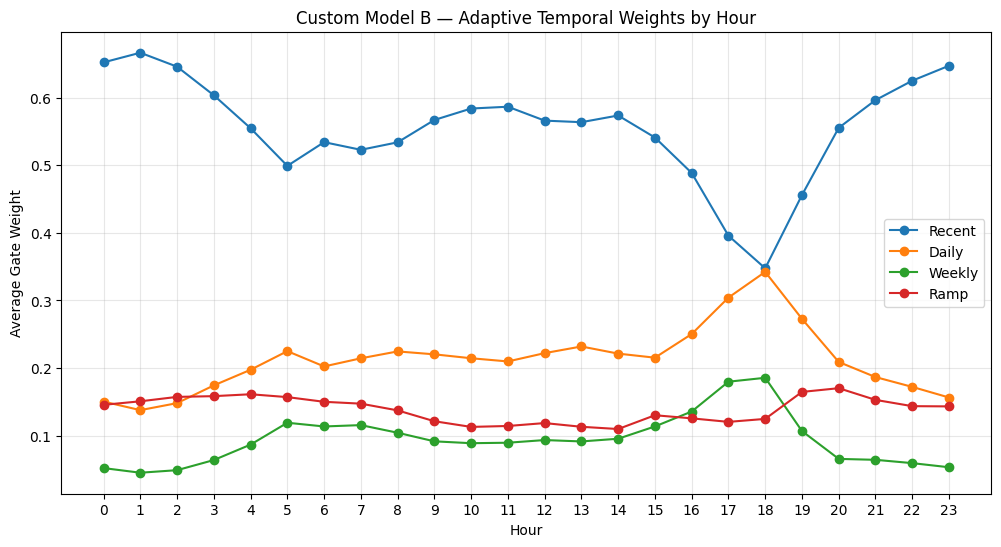

In [39]:
plt.figure(figsize=(12, 6))

for column in [
    "recent_weight",
    "daily_weight",
    "weekly_weight",
    "ramp_weight"
]:
    plt.plot(
        hourly_gate_weights.index,
        hourly_gate_weights[column],
        marker="o",
        label=column.replace("_weight", "").title()
    )

plt.xlabel("Hour")
plt.ylabel("Average Gate Weight")
plt.title(
    "Custom Model B — Adaptive Temporal Weights by Hour"
)

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()